# 📊 Сравнение алгоритмов поиска пути

В этом ноутбуке проводится экспериментальное сравнение алгоритмов поиска пути на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Сравнить следующие алгоритмы:

- A*
- Дейкстра
- Жадный (Greedy)

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути
- максимальные углы в пути (вбок и продольный)
- минимальные расстояния до препятсвия (евклидово и пиксельное)

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Запускаются все алгоритмы на одной и той же карте.
3. Метрики записываются в CSV файл.
4. Максимально допустимые углы вперед/назад и вбок = 30 градусам
5. Всего 100 запусков каждого алгоритма

#### 📌 Важно

Все алгоритмы сравниваются **на одинаковых входных данных**, что позволяет делать корректные выводы о производительности и качестве решений.

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод
4. Парное сравнение
- Собрать парные датасеты (A* vs Dijekstra) и  (A* vs Greedy)
- Насколько A* лучше Dijekstra
- Вывод
- Преимущетсва и недостатки Greedy перед A*
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/graph.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithmName,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound,minObstacleDistance,minObstacleDistancePixel,maxSideAngle,maxUpDownAngle
0,graph,A*,0.011267,0,0,0.00,0,0,0.0,0,0.0000,0.0000
1,graph,Dijkstra,0.007003,0,0,0.00,0,0,0.0,0,0.0000,0.0000
2,graph,Greedy,0.010477,0,0,0.00,0,0,0.0,0,0.0000,0.0000
3,graph,A*,2.281890,40,276,1540.43,1326,1,3.0,3,27.7116,20.2384
4,graph,Dijkstra,6.223470,40,984,1540.43,1326,1,3.0,3,27.7116,20.2384


In [2]:
graph = df[df["environment"] == "graph"]
success = (
    graph.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
A*              91    100  0.91       91.0
Dijkstra        91    100  0.91       91.0
Greedy          34    100  0.34       34.0


### 2) Небольшая очистка/подготовка

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               300 non-null    object 
 1   algorithmName             300 non-null    object 
 2   executionTimeMs           300 non-null    float64
 3   pathNodes                 300 non-null    int64  
 4   expandedNodes             300 non-null    int64  
 5   euclideanLength           300 non-null    float64
 6   pixelLength               300 non-null    int64  
 7   pathFound                 300 non-null    int64  
 8   minObstacleDistance       300 non-null    float64
 9   minObstacleDistancePixel  300 non-null    int64  
 10  maxSideAngle              300 non-null    float64
 11  maxUpDownAngle            300 non-null    float64
dtypes: float64(5), int64(5), object(2)
memory usage: 28.2+ KB


In [4]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(int)

df["minObstacleDistance"] = df["minObstacleDistance"].astype(float)
df["minObstacleDistancePixel"] = df["minObstacleDistancePixel"].astype(int)
df["maxSideAngle"] = df["maxSideAngle"].astype(float)
df["maxUpDownAngle"] = df["maxUpDownAngle"].astype(float)

In [5]:
# разделяем по алгоритмам
astar = graph[graph["algorithmName"] == "A*"].reset_index(drop=True)
dijkstra = graph[graph["algorithmName"] == "Dijkstra"].reset_index(drop=True)
greedy = graph[graph["algorithmName"] == "Greedy"].reset_index(drop=True)

# проверяем что строки совпадают по run-логике
n = min(len(astar), len(dijkstra), len(greedy))

astar = astar.iloc[:n]
dijkstra = dijkstra.iloc[:n]
greedy = greedy.iloc[:n]

In [6]:
mask = (
    (astar["pathFound"] == 1) &
    (dijkstra["pathFound"] == 1) &
    (greedy["pathFound"] == 1)
)

astar = astar[mask].reset_index(drop=True)
dijkstra = dijkstra[mask].reset_index(drop=True)
greedy = greedy[mask].reset_index(drop=True)

In [7]:
graph_ok = pd.concat([astar, dijkstra, greedy], ignore_index=True)

### 3) Базовая статистика


=========== executionTimeMs ===========
                mean  median    std    min    max
algorithmName                                    
A*             3.666   3.696  0.689  2.282  4.839
Dijkstra       6.212   6.204  0.288  5.640  6.913
Greedy         0.296   0.278  0.124  0.172  0.937


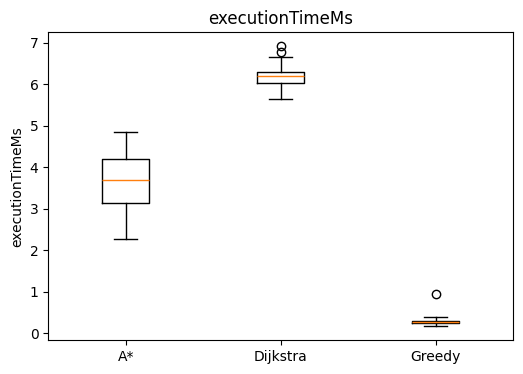


=========== expandedNodes ===========
                   mean  median     std  min   max
algorithmName                                     
A*              462.324   465.0  90.491  276   615
Dijkstra       1005.765  1007.0  28.374  934  1066
Greedy           50.735    51.0   8.840   29    66


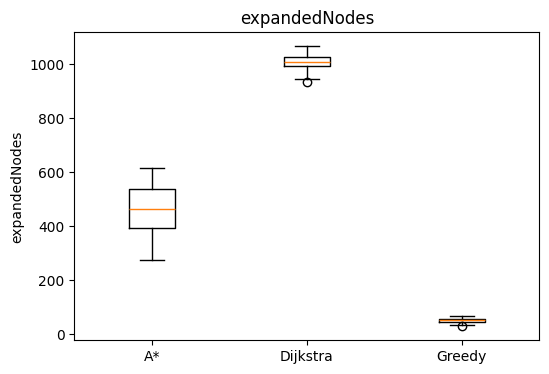


=========== pathNodes ===========
                 mean  median    std  min  max
algorithmName                                 
A*             52.206    53.5  9.178   30   66
Dijkstra       52.206    53.5  9.178   30   66
Greedy         51.735    52.0  8.840   30   67


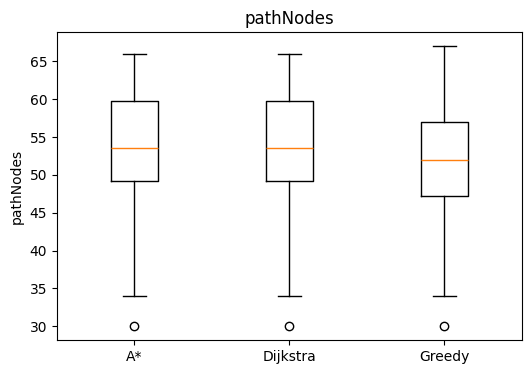


=========== euclideanLength ===========
                   mean   median      std      min      max
algorithmName                                              
A*             1605.318  1603.35   33.270  1540.43  1673.54
Dijkstra       1605.318  1603.35   33.270  1540.43  1673.54
Greedy         1844.240  1817.81  147.063  1570.08  2182.87


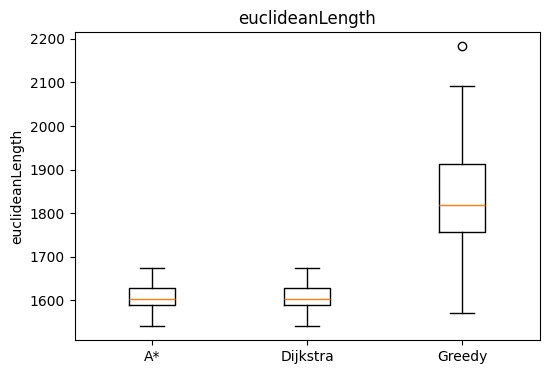


=========== pixelLength ===========
                   mean  median      std   min   max
algorithmName                                       
A*             1422.618  1426.0   53.053  1296  1532
Dijkstra       1422.618  1426.0   53.053  1296  1532
Greedy         1671.235  1658.5  163.292  1353  2051


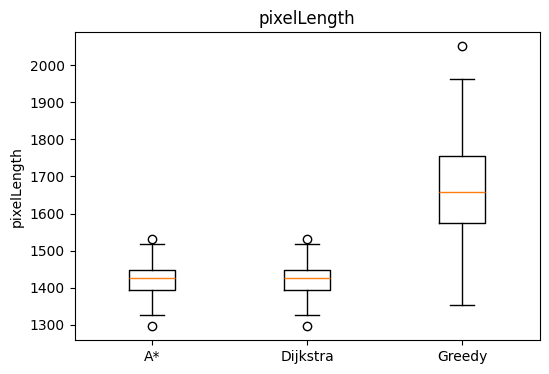


=========== minObstacleDistance ===========
                mean  median    std  min  max
algorithmName                                
A*             2.829     3.0  0.341  2.0  3.0
Dijkstra       2.829     3.0  0.341  2.0  3.0
Greedy         2.881     3.0  0.294  2.0  3.0


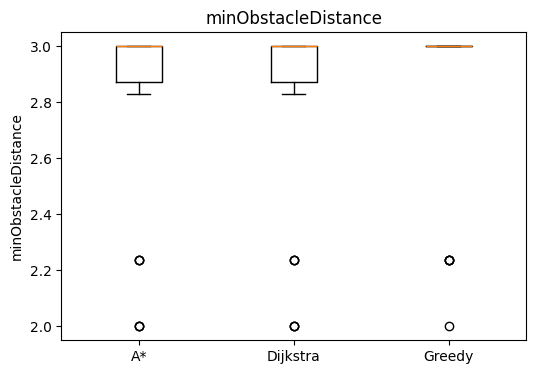


=========== minObstacleDistancePixel ===========
                mean  median    std  min  max
algorithmName                                
A*             2.912     3.0  0.288    2    3
Dijkstra       2.912     3.0  0.288    2    3
Greedy         2.971     3.0  0.171    2    3


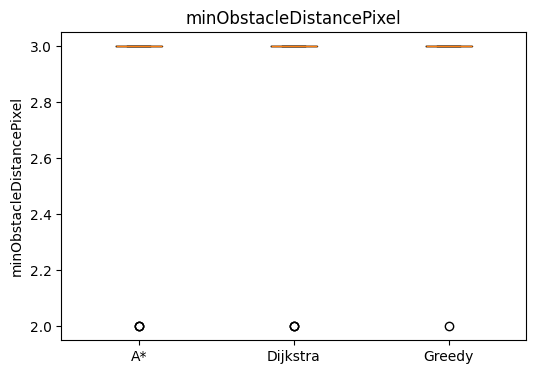


=========== maxSideAngle ===========
                 mean  median    std     min     max
algorithmName                                       
A*             26.997  27.917  3.029  15.760  29.836
Dijkstra       26.997  27.917  3.029  15.760  29.836
Greedy         27.514  28.535  2.730  20.187  32.284


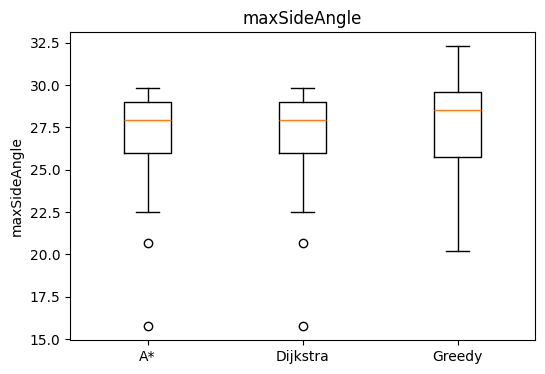


=========== maxUpDownAngle ===========
                 mean  median   std     min     max
algorithmName                                      
A*             23.583  24.868  4.86  11.929  29.957
Dijkstra       23.583  24.868  4.86  11.929  29.957
Greedy         22.750  23.108  5.19  12.865  29.749


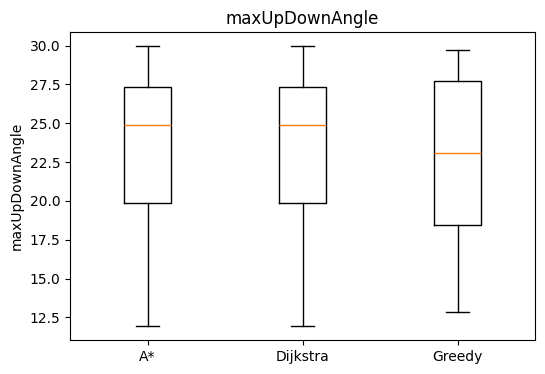

In [8]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "minObstacleDistance",
    "minObstacleDistancePixel",
    "maxSideAngle",
    "maxUpDownAngle"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        graph_ok.groupby("algorithmName")[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(6, 4))

    plt.boxplot([
        astar[metric],
        dijkstra[metric],
        greedy[metric]
    ], tick_labels=["A*", "Dijkstra", "Greedy"])

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

Базовая статистика подтверждает ожидаемые свойства исследуемых алгоритмов. Алгоритмы A* и Дейкстры демонстрируют практически идентичные характеристики построенных маршрутов: число вершин пути, его евклидова и пиксельная длины совпадают во всех проведённых экспериментах. Это свидетельствует о том, что оба метода находят одинаковые пути на заданном навигационном графе, различаясь лишь стратегией поиска. При этом A* достигает результата за существенно меньшее время и с меньшим числом расширенных вершин благодаря использованию эвристической функции, что подтверждает его вычислительную эффективность по сравнению с полным обходом в алгоритме Дейкстры.

Жадный алгоритм демонстрирует наименьшее время работы и минимальное число обработанных вершин, однако это достигается за счёт существенного ухудшения качества и надёжности решения. В среднем он строит более длинные маршруты и значительно чаще не находит путь: успешность поиска составляет порядка 30%, тогда как A* и алгоритм Дейкстры успешно находят путь примерно в 90% случаев на одинаковом наборе тестовых карт.

Поскольку поиск осуществляется на навигационном графе, построенном на основе диаграммы Вороного с учётом ограничений по радиусу тележки и допустимым углам наклона, все алгоритмы формируют геометрически корректные и безопасные маршруты в рамках заданных ограничений. Это подтверждается стабильными значениями минимального расстояния до препятствий и ограниченными значениями максимальных углов на всех успешных траекториях.

Таким образом, уже на этапе базовой статистики наблюдается характерный компромисс между скоростью поиска, качеством найденного маршрута и полнотой поиска. Количественная оценка этих различий будет выполнена в следующем разделе с использованием парного сравнения алгоритмов.

### 4) Парное сравнение

#### A* vs Dijekstra

Смотрим отношения врмени и обработанных вершин (остальные метрики у них совпадают)

In [9]:
time_ratio = (
    dijkstra["executionTimeMs"].to_numpy()
    / astar["executionTimeMs"].to_numpy()
)

expanded_ratio = (
    dijkstra["expandedNodes"].to_numpy()
    / astar["expandedNodes"].to_numpy()
)

comparison = pd.DataFrame({
    "Time ratio": time_ratio,
    "Expanded nodes ratio": expanded_ratio
})

comparison.agg(["mean", "median", "std", "min", "max"]).round(3)

,Time ratio,Expanded nodes ratio
mean,1.755,2.263
median,1.699,2.194
std,0.342,0.473
min,1.283,1.637
max,2.727,3.565


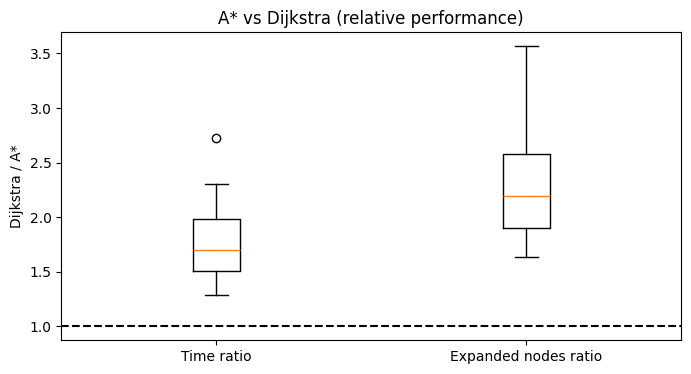

In [10]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    [time_ratio, expanded_ratio],
    tick_labels=["Time ratio", "Expanded nodes ratio"]
)

plt.axhline(1.0, linestyle="--", color="black")

plt.title("A* vs Dijkstra (relative performance)")
plt.ylabel("Dijkstra / A*")

plt.show()

##### Вывод (A* vs Dijkstra)

Парное сравнение алгоритмов показывает устойчивое преимущество A* над алгоритмом Дейкстры по времени выполнения и количеству расширенных вершин при сохранении идентичного качества найденного пути.

По времени работы A* в среднем оказывается быстрее примерно в 1.5 раза, при этом наблюдается умеренный разброс значений, что указывает на зависимость ускорения от структуры конкретного графа.

Более выраженный эффект наблюдается по числу расширенных вершин: A* в среднем исследует в 2 раза меньше узлов, чем алгоритм Дейкстры. Это подтверждает эффективность эвристической компоненты в сокращении пространства поиска.

Таким образом, A* демонстрирует систематическое снижение вычислительных затрат при сохранении оптимальности решения, а выигрыш особенно заметен в метрике числа расширенных состояний, что согласуется с теоретическими свойствами алгоритма.

#### A* vs Greedy

Подготовка метрик


=== time_ratio ===
mean      0.081
median    0.073
std       0.028
min       0.049
max       0.223
Name: time_ratio, dtype: float64


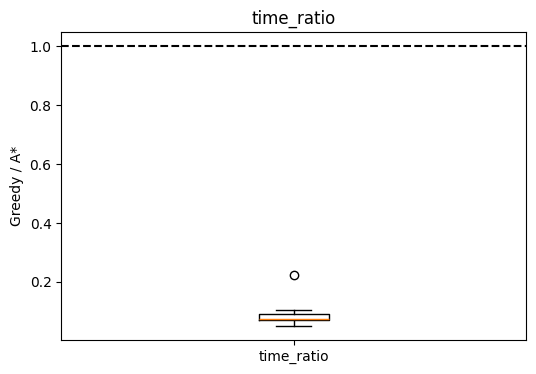


=== expandedNodes_ratio ===
mean      0.112
median    0.109
std       0.020
min       0.071
max       0.167
Name: expandedNodes_ratio, dtype: float64


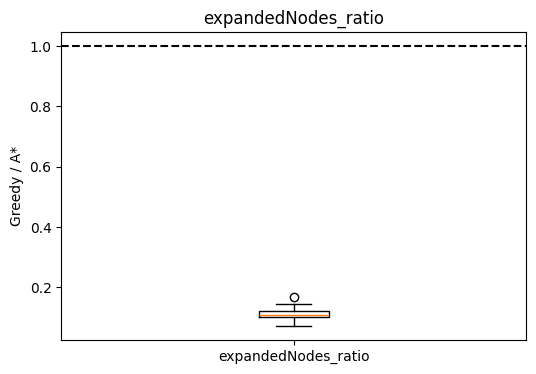


=== path_nodes_ratio ===
mean      1.000
median    1.008
std       0.123
min       0.742
max       1.343
Name: path_nodes_ratio, dtype: float64


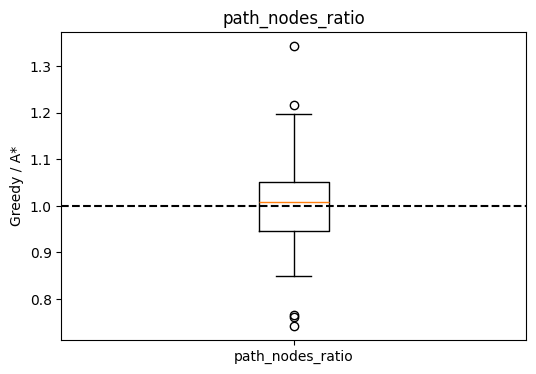


=== euclid_ratio ===
mean      1.148
median    1.136
std       0.081
min       1.000
max       1.374
Name: euclid_ratio, dtype: float64


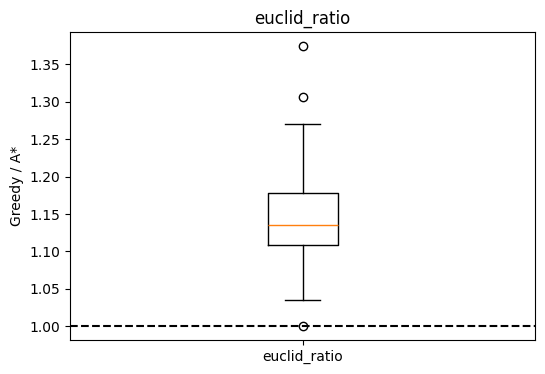


=== pixel_ratio ===
mean      1.174
median    1.157
std       0.099
min       1.000
max       1.504
Name: pixel_ratio, dtype: float64


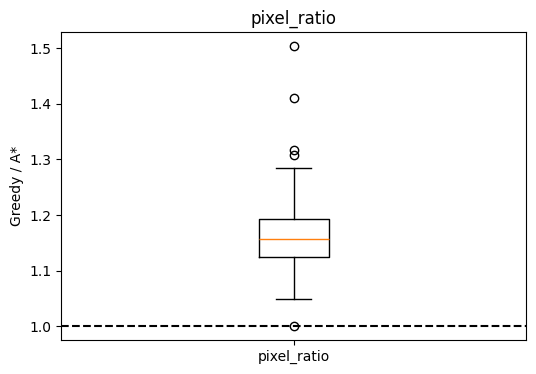


=== minObstacleDistance_ratio ===
mean      1.032
median    1.000
std       0.163
min       0.745
max       1.500
Name: minObstacleDistance_ratio, dtype: float64


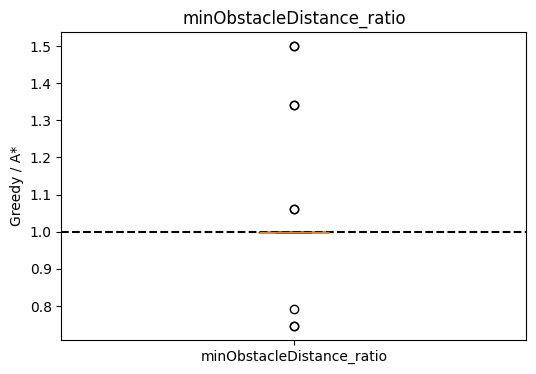


=== minObstacleDistancePixel_ratio ===
mean      1.029
median    1.000
std       0.119
min       1.000
max       1.500
Name: minObstacleDistancePixel_ratio, dtype: float64


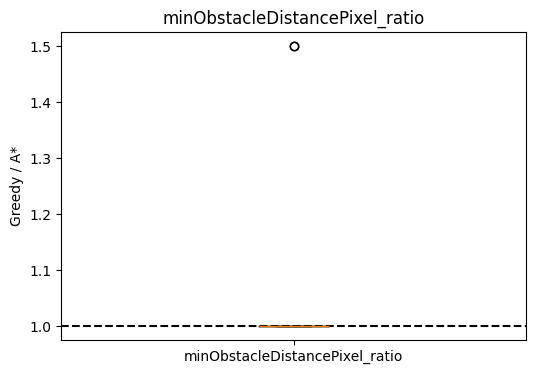


=== maxSideAngle_ratio ===
mean      1.032
median    1.000
std       0.174
min       0.824
max       1.876
Name: maxSideAngle_ratio, dtype: float64


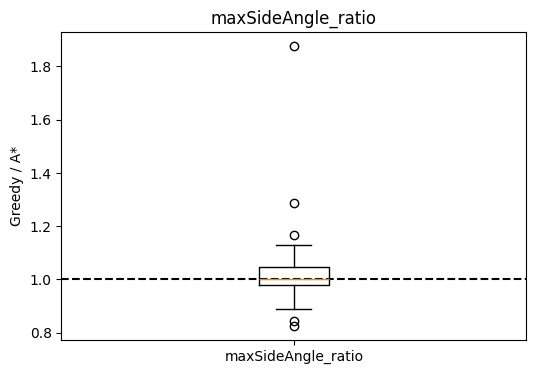


=== maxUpDownAngle_ratio ===
mean      1.002
median    1.000
std       0.288
min       0.488
max       1.609
Name: maxUpDownAngle_ratio, dtype: float64


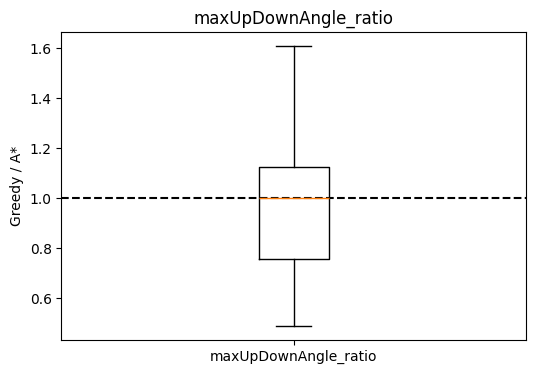

In [11]:
ratios = {
    "time_ratio": greedy["executionTimeMs"].to_numpy() / astar["executionTimeMs"].to_numpy(),
    "expandedNodes_ratio": greedy["expandedNodes"].to_numpy() / astar["expandedNodes"].to_numpy(),
    "path_nodes_ratio": greedy["pathNodes"].to_numpy() / astar["pathNodes"].to_numpy(),
    "euclid_ratio": greedy["euclideanLength"].to_numpy() / astar["euclideanLength"].to_numpy(),
    "pixel_ratio": greedy["pixelLength"].to_numpy() / astar["pixelLength"].to_numpy(),
    "minObstacleDistance_ratio": greedy["minObstacleDistance"].to_numpy() / astar["minObstacleDistance"].to_numpy(),
    "minObstacleDistancePixel_ratio": greedy["minObstacleDistancePixel"].to_numpy() / astar["minObstacleDistancePixel"].to_numpy(),
    "maxSideAngle_ratio": greedy["maxSideAngle"].to_numpy() / astar["maxSideAngle"].to_numpy(),
    "maxUpDownAngle_ratio": greedy["maxUpDownAngle"].to_numpy() / astar["maxUpDownAngle"].to_numpy(),
}

ratio_df = pd.DataFrame(ratios)

for name in ratio_df.columns:
    print(f"\n\033[1m=== {name} ===\033[0m")

    summary = ratio_df[name].agg(["mean", "median", "std", "min", "max"]).round(3)
    print(summary)

    plt.figure(figsize=(6, 4))

    plt.boxplot([ratio_df[name]], tick_labels=[name])
    plt.axhline(1.0, linestyle="--", color="black")

    plt.title(name)
    plt.ylabel("Greedy / A*")

    plt.show()

##### Вывод (Greedy vs A*)

Парное сравнение алгоритмов Greedy и A* демонстрирует выраженный компромисс между вычислительной эффективностью и качеством решения.

По времени выполнения Greedy существенно превосходит A*, обеспечивая ускорение в среднем примерно в 15–20 раз (среднее отношение времени ≈ 0.064). Аналогичная тенденция наблюдается и по числу обработанных вершин: Greedy рассматривает в среднем лишь около 12% от количества узлов, обрабатываемых A*, что подтверждает его значительно меньшую вычислительную сложность.

Однако это ускорение достигается ценой ухудшения качества найденного маршрута. Длина пути, построенного Greedy, в среднем увеличивается примерно на 14–17% (средние значения коэффициентов для евклидовой и пиксельной длины составляют ≈ 1.15–1.17). При этом наблюдается заметная вариативность результатов, что указывает на высокую зависимость качества решения от локальной структуры графа.

Отдельно следует отметить, что Greedy не гарантирует полноту поиска: в части экспериментов алгоритм не смог найти путь, тогда как A* успешно находил корректное решение в подавляющем большинстве случаев. Это подчёркивает фундаментальное отличие эвристического жадного поиска от алгоритма, сохраняющего баланс между оптимальностью и полнотой.

Интересно, что по геометрическим ограничениям (минимальная дистанция до препятствий и углы наклона) оба алгоритма демонстрируют близкие значения, что объясняется общей структурой навигационного графа и едиными условиями проходимости. Это означает, что различия между алгоритмами проявляются прежде всего в стратегии обхода графа, а не в допустимых конфигурациях траектории.

Таким образом, Greedy демонстрирует максимальную скорость работы и минимальные вычислительные затраты, но проигрывает по надёжности и качеству маршрута. В отличие от него, A* обеспечивает более устойчивые и качественные решения за счёт увеличенных вычислительных затрат.